# Simulation Results of the ```IBB Transformer and Load``` model
Plotting of the simulation results, saving them and comparing to PowerFactory Data.

## 0 Imports and predefinitions

In [9]:
import numpy as np
import os
import sys
import pandas as pd

parent = os.path.abspath("/Users/maxikoehler/Documents/GitHub/diffpssi-ma-kohler/")
sys.path.insert(1, parent)
sys.path.append(
    str(os.path.dirname(os.path.dirname(os.path.abspath("ibb_trans_notebook.ipynb"))))
)

import matplotlib.pyplot as plt
import matplotlib as mpl
from tools.colors import *

# Set the matplotlib settings
plt.rcParams.update(
    {
        "font.family": "Charter",
        "font.size": 12,
        "figure.autolayout": True,
        "text.usetex": True,
    }
)
mpl.rcParams["axes.prop_cycle"] = mpl.cycler(
    color=[ees_blue, ees_yellow, ees_green, ees_red, ees_lightblue]
)

import development_files.examples.ibb_transformer.ibb_trans_model as mdl
from src.diffpssi.power_sim_lib.simulator import PowerSystemSimulation as Pss
from src.diffpssi.power_sim_lib.simulator import Recorder
from tools.calcs import *

In [10]:
BACKEND = "numpy"  # 'torch' or 'numpy'
DEFAULT_DEVICE = "cpu"  # 'cuda' or 'cpu'

if os.environ.get("DIFFPSSI_SIM_BACKEND") is not None:
    BACKEND = os.environ.get("DIFFPSSI_SIM_BACKEND")

if BACKEND == "torch":
    import torch
    import numpy

    torch.pi = numpy.pi
    print("Using torch as backend")
    if torch.cuda.is_available() and (
        DEFAULT_DEVICE == "cuda" or DEFAULT_DEVICE == "gpu"
    ):
        torch.set_default_device("cuda")
        print("Using torch with CUDA on GPU")
    else:
        print("Using torch on CPU")

elif BACKEND == "numpy":
    import numpy as torch

    torch.tensor = torch.array
    torch.unsqueeze = torch.expand_dims
    print("Using numpy as backend")
else:
    raise ValueError("No backend specified")

Using numpy as backend


## 1 Sim Setup and Run

In [11]:
def record_dict(simulation, call=False):
    record_dict = {
        "Bus 0: voltage magnitude": simulation.busses[0].get_value("voltage_mag"),
        "Bus 1: voltage magnitude": simulation.busses[1].get_value("voltage_mag"),
        "Bus 2: voltage magnitude": simulation.busses[2].get_value("voltage_mag"),
        # 'v_dead':                       simulation.trafos[0].oltc.v_dead,
        # 'v_diff':                       simulation.trafos[0].oltc.v_diff,
        # 'Integrator M: State':          simulation.trafos[0].oltc.integrator_m.state_1,
        # 'Integrator K: State':          simulation.trafos[0].oltc.integrator_k.state_1,
        # 'integ_m':                      simulation.trafos[0].oltc.integ_m,
        # 'integ_k':                      simulation.trafos[0].oltc.integ_k,
        # 'Position M':                   simulation.trafos[0].oltc.tap_pos_m,
        # 'Position K':                   simulation.trafos[0].oltc.tap_pos_k,
        r"Transformer $u_\mathrm{l}$": simulation.trafos[0].oltc.u_l,
    }
    if call:
        return record_dict.values()
    else:
        return record_dict

In [12]:
parallel_sims = 1
sim = Pss(
    parallel_sims=parallel_sims,
    sim_time=120,
    time_step=0.005,
    solver="heun",
    grid_data=mdl.load(),
    # jacobi_calculation=True,
    # verbose=False,
)

start = 1
end = 1.05

# sim.add_sc_event(start, end, 'Bus 0')
sim.add_param_event(
    1, sim.busses[1].models[0], "p_soll_mw", 14 * sim.busses[1].models[0].p_soll_mw
)
# sim.add_param_event(1, sim.busses[1].models[0], 'y_load', 7*sim.busses[1].models[0].y_load)

rec = Recorder(sim=sim, recorder_dict=record_dict)

sim.set_record_function(rec.record_fun)
record_list = rec.record_list()

t, recorder = sim.run()

Load flow finished in 3 iterations with error 1.67e-10 in 0.0461 seconds


100%|██████████| 24001/24001 [00:11<00:00, 2156.46it/s]

Dynamic simulation finished in 11.18 seconds


### 1.X Some details of whats going on

In [13]:
# fig, axs = plt.subplots(len(record_list)-4, 1, sharex=True)

# for i in range(len(record_list)-4):
#     axs[i].plot(t, recorder[0, :, i+3], label=record_list[i+3])
#     axs[i].grid()
#     axs[i].set_ylabel(record_list[i+3])

# plt.show()

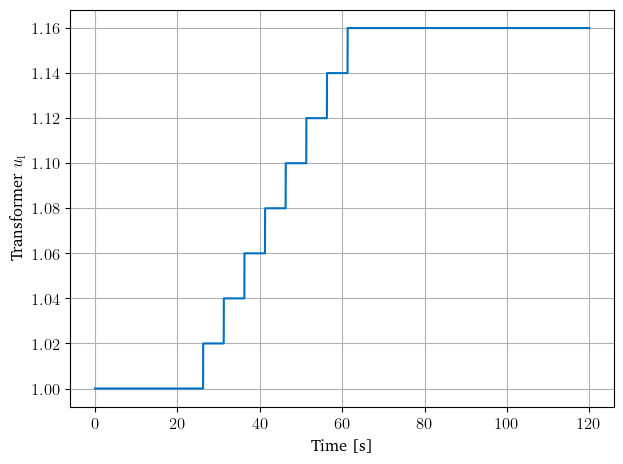

In [14]:
plt.figure()

plt.plot(t, recorder[0, :, -1], label=record_list[-1])
plt.grid()
plt.ylabel(record_list[-1])
plt.xlabel("Time [s]")

plt.show()

## 2 Saving data, generation and saving of plots 

### 2.1 Only the Simulation Data from ```diffpssi```

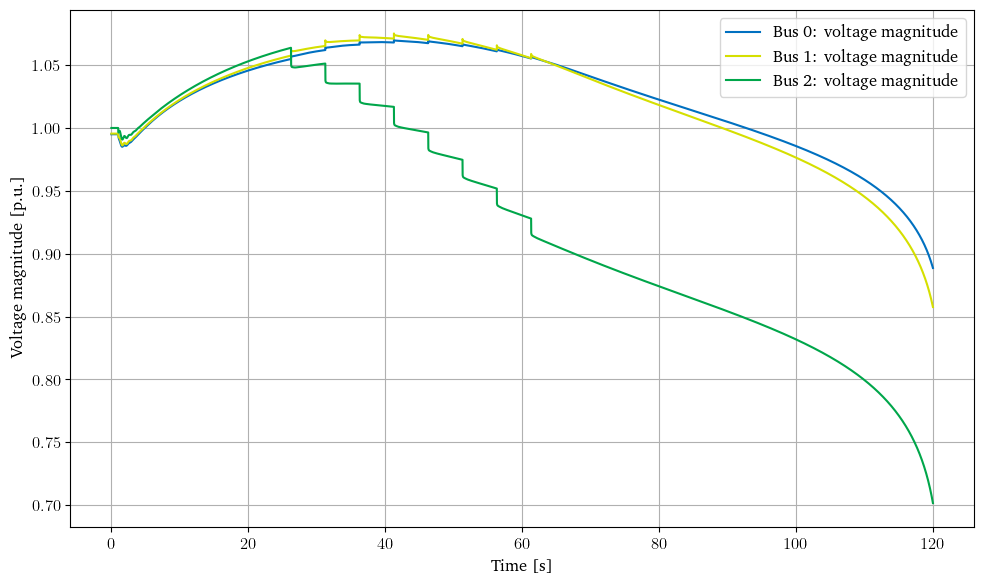

In [15]:
plt.figure(figsize=(10, 6))
for i in range(3):
    plt.plot(t, recorder[0, :, i], label=record_list[i])
plt.grid()
plt.legend()
# plt.ylim(0.9, 1.15)
plt.xlabel("Time [s]")
plt.ylabel("Voltage magnitude [p.u.]")
plt.show()

In [16]:
data = pd.DataFrame(recorder[0, :, :])
data.columns = record_list
data["t"] = t
data.set_index("t", inplace=True)

data.to_csv("./data/ibb_transformer.csv")

data.head()

,Bus 0: voltage magnitude,Bus 1: voltage magnitude,Bus 2: voltage magnitude,Transformer $u_\mathrm{l}$
t,,,,
0.000,0.995,0.995504,1.0,1.0
0.005,0.995,0.995504,1.0,1.0
0.010,0.995,0.995504,1.0,1.0
0.015,0.995,0.995504,1.0,1.0
0.020,0.995,0.995504,1.0,1.0


### 2.2 Loading the Data from PowerFactory

In [17]:
data_pf = pd.read_csv(
    "./data/ibb_load-inc_simple-transformer_valid_2.csv", sep=";", dtype=float
)
data_pf.rename(
    columns={
        "Time in s": "t",
        "Voltage, Magnitude in p.u.": "Bus 0: voltage magnitude",
        "Voltage, Magnitude in p.u..1": "Bus 1: voltage magnitude",
        "Voltage, Magnitude in p.u..2": "Bus 2: voltage magnitude",
    },
    inplace=True,
)
data_pf.set_index("t", inplace=True)

data_pf.head()

,Bus 0: voltage magnitude,Bus 1: voltage magnitude,Bus 2: voltage magnitude
t,,,
0.000,0.995,0.993242,1.0
0.005,0.995,0.993242,1.0
0.010,0.995,0.993242,1.0
0.015,0.995,0.993242,1.0
0.020,0.995,0.993242,1.0


### 2.3 Comparing the Data: ```diffpssi``` vs. PowerFactory

In [18]:
time = data.index

# Calculate mean error
mean_errors = np.zeros((3, len(time)))
for i in range(3):
    ext_voltages = data_pf.iloc[:, i].values
    model_voltage = data.iloc[:, 1].values
    errors = [
        abs(ext_v - model_v) for model_v, ext_v in zip(model_voltage, ext_voltages)
    ]
    mean_errors[i] = errors

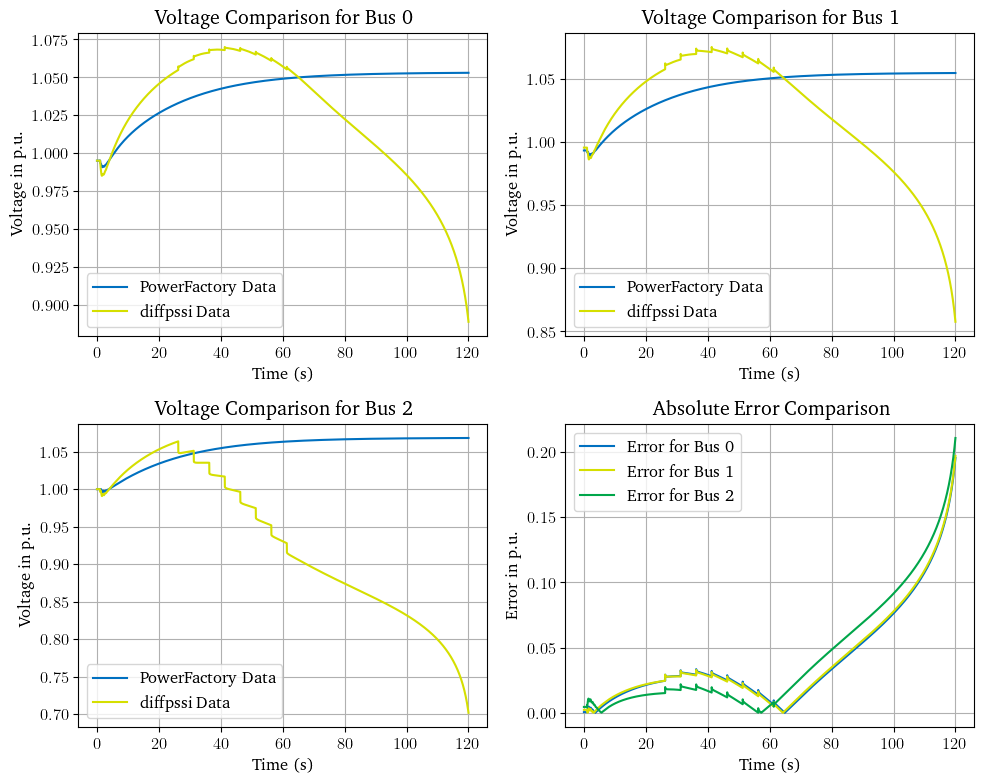

In [19]:
fig, axs = plt.subplots(2, 2, figsize=(10, 8))

for i in range(3):
    row, col = divmod(i, 2)
    axs[row, col].plot(
        data_pf.index.values, data_pf.iloc[:, i].values, label="PowerFactory Data"
    )
    axs[row, col].plot(
        time, data.iloc[:, i].values, linestyle="-", label="diffpssi Data"
    )
    axs[row, col].set_title(f"Voltage Comparison for Bus {i}")
    axs[row, col].set_xlabel("Time (s)")
    axs[row, col].set_ylabel("Voltage in p.u.")
    axs[row, col].legend()
    axs[row, col].grid(True)

# Add mean error plot
axs[1, 1].plot(time, mean_errors[0], label="Error for Bus 0")
axs[1, 1].plot(time, mean_errors[1], label="Error for Bus 1")
axs[1, 1].plot(time, mean_errors[2], label="Error for Bus 2")
axs[1, 1].set_ylabel("Error in p.u.")
axs[1, 1].set_title("Absolute Error Comparison")
axs[1, 1].set_xlabel("Time (s)")
axs[1, 1].legend()
axs[1, 1].grid(True)

plt.tight_layout()
# plt.savefig('./examples/master_thesis/ibb_transformer/data/comp_simple_pi.pdf')
plt.show()